# Notebook 1: Your First Neural Network - Predicting Rain with PyTorch

Ghana AI Talent Accelerator - Deep Learning Foundations

Ghana AI Accelerator

<a href="https://colab.research.google.com/github/sisengai/TrainingMaterials/blob/main/intro_DL1.ipynb" target="_parent">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Philosophy: First the Fire, Then the Physics

Most courses teach you how to build a carburetor before letting you
drive a car. **We do the opposite.**

We start by training a working model. Once you’ve seen it work, we peel
back the layers to understand why. This “Top-Down” approach, pioneered
by Jeremy Howard (fast.ai), ensures you stay motivated by solving real
problems immediately.

**Day One Goal:** Train a rain predictor in 30 minutes.  
**Day Thirty Goal:** Understand why changing the learning rate from
0.001 to 0.01 collapsed your loss curve.

This follows the mantra: **“You don’t need to understand the carburetor
to drive a car, but you’ll want to when it breaks down.”**

------------------------------------------------------------------------

# The Problem: Will It Rain Tomorrow?

## Why This Problem?

We’re going to build a neural network that predicts whether it will rain
tomorrow based on today’s weather data. This is a perfect first problem
because:

-   **Relatable**: Everyone understands weather
-   **Tabular data**: Simple numbers, not complex images
-   **Binary classification**: Yes/No answer (easier than 10-class digit
    classification)
-   **Real data**: Australian weather measurements from multiple
    stations
-   **Class imbalance**: Teaches important real-world challenges

## The Dataset

We’ll use the Australian Weather dataset, which contains daily
measurements from multiple weather stations. Each row represents one
day’s weather with features like:

-   **Rainfall**: How much rain fell today (mm)
-   **Humidity3pm**: Humidity percentage at 3 PM
-   **Pressure9am**: Atmospheric pressure at 9 AM (hPa)
-   **RainToday**: Did it rain today? (Yes/No)
-   **RainTomorrow**: Will it rain tomorrow? (Yes/No) ← Our target

Let’s load and explore the data:

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# Set style for plots
sns.set(style='whitegrid', palette='muted', font_scale=1.2)
%matplotlib inline

# Set random seeds for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# Device setup - use GPU if available
import warnings
warnings.filterwarnings('ignore')
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

### Load the Data

We’ll use the Australian Weather dataset from the provided URL:

In [ ]:
# Download and load the weather dataset
url = "https://raw.githubusercontent.com/gchoi/Dataset/refs/heads/master/weatherAUS.csv"
df = pd.read_csv(url)

print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn names:")
print(df.columns.tolist())

### Data Preprocessing

Neural networks only understand numbers. We need to:

1.  Select relevant features (we’ll use 4 key features for simplicity)
2.  Convert “Yes”/“No” to 1/0
3.  Handle any missing values
4.  Split into features (X) and target (y)
5.  Convert to PyTorch tensors

In [ ]:
# Select the features we want to use
# We'll focus on these 4 features that are good predictors of rain:
features = ['Rainfall', 'Humidity3pm', 'Pressure9am', 'RainToday', 'RainTomorrow']
df = df[features].copy()

print("Selected columns:")
print(df.columns.tolist())
print(f"\nDataset shape: {df.shape}")

# Check the first few rows
print("\nFirst 5 rows:")
print(df.head())

In [ ]:
# Convert categorical variables to numeric
df['RainToday'] = df['RainToday'].map({'No': 0, 'Yes': 1})
df['RainTomorrow'] = df['RainTomorrow'].map({'No': 0, 'Yes': 1})

# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal rows: {len(df)}")

# Drop any rows with missing values (simple approach for this tutorial)
df = df.dropna()

print(f"\nDataset shape after cleaning: {df.shape}")
print("\nData types:")
print(df.dtypes)

### Understanding Class Imbalance

In [ ]:
# Check class distribution
class_counts = df['RainTomorrow'].value_counts()
print("Class distribution:")
print(class_counts)
print(f"\nPercentage:")
print((class_counts / len(df) * 100).round(2))

# Visualize
plt.figure(figsize=(9, 6))
sns.countplot(x='RainTomorrow', data=df)
plt.title('Class Distribution: Will it rain tomorrow?', fontweight='bold')
plt.xlabel('Rain Tomorrow (0=No, 1=Yes)')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Rain (0)', 'Rain (1)'])
plt.show()

**Key Insight**: About 78% of days have no rain tomorrow, and 22% have
rain. This is **class imbalance** - a model that always predicts “no
rain” would be 78% accurate! We’ll need to be careful about this.

------------------------------------------------------------------------

# Building Our First Neural Network

## From Linear Regression to Neural Networks

**Reminder**: In traditional machine learning, Linear Regression finds:
$$\hat{y} = w_1 x_1 + w_2 x_2 + w_3 x_3 + w_4 x_4 + b$$

This works for linear relationships, but weather is complex. What if:

-   High humidity AND low pressure together matter more than either
    alone?
-   The relationship isn’t a straight line?

**Neural Network Insight**: Stack multiple linear transformations with
non-linear activations:

$$
\text{Layer 1: } h = W_1 \cdot x + b_1$$
$$\text{Activation: } a = \text{relu}(h)$$
$$\text{Layer 2: } \hat{y} = \text{sigmoid}(W_2 \cdot a + b_2)$$

## Our Network Architecture

For our rain prediction, we’ll build a simple network:

-   **Input**: 4 features (Rainfall, Humidity3pm, Pressure9am,
    RainToday)
-   **Hidden Layer 1**: 5 neurons with ReLU activation
-   **Hidden Layer 2**: 3 neurons with ReLU activation  
-   **Output**: 1 neuron with Sigmoid activation (probability of rain)

In [ ]:
# Prepare data for PyTorch
# Features: Rainfall, Humidity3pm, Pressure9am, RainToday
# Target: RainTomorrow
feature_cols = ['Rainfall', 'Humidity3pm', 'Pressure9am', 'RainToday']
X = df[feature_cols].values
y = df['RainTomorrow'].values

print("Features used:")
for i, col in enumerate(feature_cols):
    print(f"  {i+1}. {col}")

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

# Convert to PyTorch tensors
X_train = torch.from_numpy(X_train).float()
y_train = torch.from_numpy(y_train).float()
X_test = torch.from_numpy(X_test).float()
y_test = torch.from_numpy(y_test).float()

print(f"\nTraining samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Input features: {X_train.shape[1]}")

### Define the Model

In [ ]:
class RainPredictor(nn.Module):
    """
    A neural network to predict if it will rain tomorrow.
    
    Architecture:
    - Input: 4 features
    - Hidden 1: 5 neurons (ReLU)
    - Hidden 2: 3 neurons (ReLU)
    - Output: 1 neuron (Sigmoid for binary classification)
    """
    def __init__(self, n_features):
        super(RainPredictor, self).__init__()
        self.fc1 = nn.Linear(n_features, 5)
        self.fc2 = nn.Linear(5, 3)
        self.fc3 = nn.Linear(3, 1)
    
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = torch.sigmoid(self.fc3(x))
        return x

# Create model
model = RainPredictor(X_train.shape[1])
print("Model Architecture:")
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")

### Visualizing a Single Neuron

Before we understand the full network, let’s see what a single neuron
does. Each neuron receives inputs, multiplies them by weights, adds a
bias, and applies an activation function:

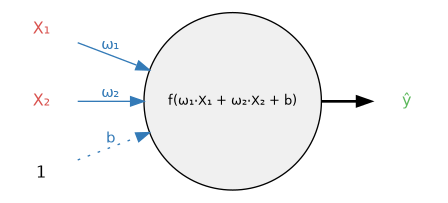

**Formula**: Output of neuron = **ŷ = f(ω₁·X₁ + ω₂·X₂ + b)**

**How it works:**

-   **Inputs** (X₁, X₂): The data coming in (e.g., rainfall, humidity)
-   **Weights** (ω₁, ω₂): How much each input matters (learned during
    training)
-   **Bias** (b): An adjustable offset (learned during training)
-   **Activation function** (f): Introduces non-linearity (ReLU,
    Sigmoid, etc.)
-   **Output** (ŷ, “y-hat”): The neuron’s predicted output

A neural network is just many of these neurons connected together!

### Understanding Activation Functions

**ReLU (Rectified Linear Unit)**: $$\text{ReLU}(x) = \max(0, x)$$

If the input is negative, output 0. If positive, pass it through. This
introduces non-linearity.

**Sigmoid**: $$\text{Sigmoid}(x) = \frac{1}{1 + e^{-x}}$$

Squishes any value to be between 0 and 1, giving us a probability.

In [ ]:
# Visualize activation functions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 6))

x = torch.linspace(-5, 5, 100)
ax1.plot(x.numpy(), F.relu(x).numpy())
ax1.set_title('ReLU Activation')
ax1.set_xlabel('Input')
ax1.set_ylabel('Output')
ax1.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax1.axvline(x=0, color='k', linestyle='--', alpha=0.3)

ax2.plot(x.numpy(), torch.sigmoid(x).numpy())
ax2.set_title('Sigmoid Activation')
ax2.set_xlabel('Input')
ax2.set_ylabel('Output')
ax2.axhline(y=0.5, color='k', linestyle='--', alpha=0.3)
ax2.axvline(x=0, color='k', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

------------------------------------------------------------------------

# The Five Sacred Steps of Training

Every neural network training loop follows these exact steps:

## Step 1: Zero Gradients

PyTorch accumulates gradients by default. We must clear them before each
batch.

``` python
optimizer.zero_grad()
```

**Why?** Imagine hiking and wanting to know which way is downhill. You
don’t want to average yesterday’s slope with today’s - you want a fresh
measurement.

## Step 2: Forward Pass

Pass data through the model to get predictions.

``` python
output = model(data)
```

## Step 3: Calculate Loss

Measure how wrong we are.

``` python
loss = criterion(output, target)
```

**Binary Cross Entropy Loss (BCELoss)**: Measures the difference between
predicted probability and true label (0 or 1).

## Step 4: Backward Pass (Backpropagation)

Calculate how much each parameter contributed to the error.

``` python
loss.backward()
```

## Step 5: Update Weights

Adjust parameters to reduce the loss.

``` python
optimizer.step()
```

## Complete Training Loop

In [ ]:
def train_model(model, X_train, y_train, X_val, y_val, n_epochs=100, lr=0.001):
    """
    Train the neural network.
    """
    # Move data to device
    X_train = X_train.to(device)
    y_train = y_train.to(device)
    X_val = X_val.to(device)
    y_val = y_val.to(device)
    model = model.to(device)
    
    # Define loss function and optimizer
    criterion = nn.BCELoss()  # Binary Cross Entropy for binary classification
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # Track history
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': []
    }
    
    for epoch in range(n_epochs):
        # Training phase
        model.train()
        
        # Forward pass
        y_pred = model(X_train)
        # Squeeze to match target shape [N] -> both should be 1D
        y_pred = y_pred.squeeze()
        if y_pred.dim() == 0:
            y_pred = y_pred.unsqueeze(0)
        
        # Calculate loss
        loss = criterion(y_pred, y_train)
        
        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Calculate training accuracy
        with torch.no_grad():
            predicted = (y_pred >= 0.5).float()
            train_acc = (predicted == y_train).float().mean()
        
        # Validation phase
        model.eval()
        with torch.no_grad():
            y_val_pred = model(X_val)
            # Squeeze to match target shape [N] -> both should be 1D
            y_val_pred = y_val_pred.squeeze()
            if y_val_pred.dim() == 0:
                y_val_pred = y_val_pred.unsqueeze(0)
            val_loss = criterion(y_val_pred, y_val)
            val_predicted = (y_val_pred >= 0.5).float()
            val_acc = (val_predicted == y_val).float().mean()
        
        # Store metrics
        history['train_loss'].append(loss.item())
        history['val_loss'].append(val_loss.item())
        history['train_acc'].append(train_acc.item())
        history['val_acc'].append(val_acc.item())
        
        # Print progress
        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch+1}/{n_epochs}')
            print(f'  Train Loss: {loss.item():.4f}, Train Acc: {train_acc.item():.4f}')
            print(f'  Val Loss: {val_loss.item():.4f}, Val Acc: {val_acc.item():.4f}')
    
    return model, history

# Split training data into train and validation
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=RANDOM_SEED
)

print(f"Training: {len(X_train_split)} samples")
print(f"Validation: {len(X_val)} samples")
print(f"Test: {len(X_test)} samples")

### Train the Model

In [ ]:
# Train the model
print("Training RainPredictor...")
print("=" * 50)

model, history = train_model(
    model, X_train_split, y_train_split, X_val, y_val, 
    n_epochs=100, lr=0.001
)

print("\nTraining complete!")

## Visualize Training Progress

In [ ]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 6))

# Loss
ax1.plot(history['train_loss'], label='Train Loss', color='blue')
ax1.plot(history['val_loss'], label='Val Loss', color='orange')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(history['train_acc'], label='Train Acc', color='blue')
ax2.plot(history['val_acc'], label='Val Acc', color='orange')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

------------------------------------------------------------------------

# Evaluation and Understanding Predictions

## Test Set Evaluation

In [ ]:
# Evaluate on test set
model.eval()
X_test_device = X_test.to(device)
y_test_device = y_test.to(device)

with torch.no_grad():
    y_pred = model(X_test_device)
    y_pred = torch.squeeze(y_pred)
    
    # Convert probabilities to binary predictions
    y_pred_binary = (y_pred >= 0.5).float()
    
    # Calculate accuracy
    test_acc = (y_pred_binary == y_test_device).float().mean()
    print(f"Test Accuracy: {test_acc.item():.4f}")
    
    # Get predictions back to CPU for sklearn metrics
    y_true = y_test_device.cpu().numpy()
    y_pred_labels = y_pred_binary.cpu().numpy()

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred_labels, target_names=['No Rain', 'Rain']))

### Understanding the Metrics

-   **Accuracy**: Overall correct predictions (but misleading with
    imbalanced data!)
-   **Precision**: Of predicted rain days, how many actually rained?
-   **Recall**: Of actual rain days, how many did we predict?
-   **F1-Score**: Harmonic mean of precision and recall

## Confusion Matrix

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Rain', 'Rain'],
            yticklabels=['No Rain', 'Rain'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## Analyzing Predictions

In [ ]:
# Show some example predictions
model.eval()
with torch.no_grad():
    sample_indices = np.random.choice(len(X_test), 10, replace=False)
    
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flatten()
    
    for i, idx in enumerate(sample_indices):
        sample = X_test[idx].unsqueeze(0).to(device)
        prob = model(sample).item()
        true_label = int(y_test[idx].item())
        pred_label = 1 if prob >= 0.5 else 0
        
        # Get feature values for display
        features = X_test[idx].numpy()
        
        axes[i].bar(['Prob'], [prob], color='green' if pred_label == true_label else 'red')
        axes[i].axhline(y=0.5, color='black', linestyle='--', alpha=0.5)
        axes[i].set_ylim(0, 1)
        axes[i].set_title(f'True: {"Rain" if true_label else "No Rain"}\nPred: {prob:.2%}')
        axes[i].set_ylabel('Probability')
    
    plt.suptitle('Sample Predictions (Green=Correct, Red=Wrong)', fontsize=14)
    plt.tight_layout()
    plt.show()

------------------------------------------------------------------------

# Understanding MNIST: Images as Numbers

Now that we’ve mastered tabular data with the weather problem, let’s
extend our knowledge to **image data**. This bridges us toward Notebook
2 where we’ll work with color images.

## What is MNIST?

MNIST (Modified National Institute of Standards and Technology) is the
“Hello World” of deep learning:

-   **70,000 images** of handwritten digits (0-9)
-   **28×28 pixels** each
-   **Grayscale**: Each pixel is a single number (0-255)
-   **Pre-cleaned and labeled**: Perfect for learning

**Why MNIST matters**: Before tackling complex RGB images, we need to
understand how images become numbers.

## An Image is Just a Grid of Numbers

Let’s load MNIST and see what images really are:

In [ ]:
from torchvision import datasets, transforms

# Download MNIST
mnist_train = datasets.MNIST('./data', train=True, download=True)

# Get first image
image, label = mnist_train[0]
print(f"Image type: {type(image)}")
print(f"Image size: {image.size}")
print(f"Label: {label}")

# Convert to numpy to see pixel values
image_array = np.array(image)
print(f"\nImage shape: {image_array.shape}")
print(f"\nPixel value range: {image_array.min()} to {image_array.max()}")
print(f"\nFirst 10x10 pixels:")
print(image_array[:10, :10])

### Visualizing the Grid

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(9, 6))
axes = axes.flatten()

for i in range(10):
    image, label = mnist_train[i]
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f'Digit: {label}', fontweight='bold')
    axes[i].axis('off')

plt.suptitle('MNIST Digits - First 10 Examples', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

**Key Insight**: What looks like a “7” to your eyes is just a 28×28 grid
of numbers to the computer!

## From 2D Image to 1D Vector

Neural networks expect flat vectors as input. We **flatten** the 28×28
grid into a 784-dimensional vector:

$$
28 \times 28 = 784 \text{ pixels}
$$

In [ ]:
# Show flattening process
sample_idx = 0
image, label = mnist_train[sample_idx]
image_array = np.array(image)

print(f"Original shape: {image_array.shape}")
print(f"Flattened shape: {image_array.flatten().shape}")
print(f"\nFirst 50 pixel values:")
print(image_array.flatten()[:50])

# Visualize the flattening
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 6))

ax1.imshow(image_array, cmap='gray')
ax1.set_title(f'Original: 28×28 Grid\nLabel: {label}', fontweight='bold')
ax1.axis('off')

# Show as a strip
ax2.imshow(image_array.flatten()[:196].reshape(1, -1), cmap='gray', aspect='auto')
ax2.set_title('Flattened: 1×784 Vector\n(First 196 pixels shown)', fontweight='bold')
ax2.set_xlabel('Pixel Index')
ax2.set_yticks([])

plt.tight_layout()
plt.show()

**Why flatten?** Neural network layers (like `nn.Linear`) work with
vectors, not matrices. Each pixel becomes one input feature.

## Simple MNIST Model

Just like our weather predictor, we can build a simple model for MNIST:

In [ ]:
class SimpleMNISTNet(nn.Module):
    """
    Simple neural network for MNIST digit classification.
    
    Architecture:
    - Input: 784 pixels (28×28 flattened)
    - Hidden: 128 neurons
    - Output: 10 classes (digits 0-9)
    """
    def __init__(self):
        super(SimpleMNISTNet, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 10)
    
    def forward(self, x):
        x = self.flatten(x)  # (batch, 1, 28, 28) -> (batch, 784)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)  # Raw logits (no softmax yet)
        return x

mnist_model = SimpleMNISTNet()
print("MNIST Model Architecture:")
print(mnist_model)

# Count parameters
total_params = sum(p.numel() for p in mnist_model.parameters())
print(f"\nTotal parameters: {total_params:,}")

**Note**: We output 10 values (one per digit) without sigmoid. For
multi-class classification, we’ll use `CrossEntropyLoss` which includes
softmax internally.

## The Power of Pixels

In [ ]:
# Visualize what each pixel contributes
fig, axes = plt.subplots(2, 5, figsize=(9, 6))
axes = axes.flatten()

for digit in range(10):
    # Find first example of this digit
    for i in range(len(mnist_train)):
        _, label = mnist_train[i]
        if label == digit:
            image, _ = mnist_train[i]
            break
    
    axes[digit].imshow(image, cmap='gray')
    axes[digit].set_title(f'Digit {digit}\nShape: {np.array(image).shape}', 
                         fontsize=9, fontweight='bold')
    axes[digit].axis('off')

plt.suptitle('MNIST: 10 Different Classes, Same Input Shape', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Bridge to Notebook 2**: MNIST is grayscale (1 channel). In Notebook 2,
we’ll work with **RGB images** which have 3 channels (Red, Green, Blue).
That’s 3× more pixel data!

------------------------------------------------------------------------

# The Chain Rule and Backpropagation: How Networks Learn

We’ve trained models, but **how** do they actually learn? The answer
lies in calculus and the **chain rule**.

## Why This Matters

A neural network with just 1,000 parameters has 1,000 knobs to turn.
Finding the right settings manually would be impossible. We need an
**algorithmic** way to adjust them.

**The Goal**: Minimize the loss function by adjusting weights.

## The Chain Rule: The Foundation of Backpropagation

Remember from calculus: The chain rule tells us how to compute
derivatives of composite functions.

If we have: $$y = f(g(x))$$

Then: $$\frac{dy}{dx} = \frac{dy}{dg} \cdot \frac{dg}{dx}$$

**In neural networks**, we have many composed functions:

$$
\text{Loss} = L(\text{Sigmoid}(\text{Linear}_2(\text{ReLU}(\text{Linear}_1(x)))))
$$

To find how a weight $w$ in the first layer affects the loss:

$$
\frac{\partial \text{Loss}}{\partial w} = 
\frac{\partial \text{Loss}}{\partial \text{Output}} \cdot
\frac{\partial \text{Output}}{\partial \text{Layer2}} \cdot
\frac{\partial \text{Layer2}}{\partial \text{Layer1}} \cdot
\frac{\partial \text{Layer1}}{\partial w}
$$

### Visual Example

In [ ]:
# Create a visualization of the chain rule
fig, ax = plt.subplots(figsize=(9, 6))
ax.axis('off')

# Draw the computation graph
boxes = [
    ('Input\n(x)', 0.1, 0.5),
    ('Layer 1\n(W₁x+b₁)', 0.3, 0.5),
    ('ReLU', 0.5, 0.5),
    ('Layer 2\n(W₂a+b₂)', 0.7, 0.5),
    ('Sigmoid', 0.9, 0.5),
    ('Loss\n(L)', 1.1, 0.5),
]

for text, x, y in boxes:
    ax.add_patch(plt.Rectangle((x-0.05, y-0.08), 0.1, 0.16, 
                                facecolor='lightblue', edgecolor='black', linewidth=2))
    ax.text(x, y, text, ha='center', va='center', fontsize=9, fontweight='bold')

# Draw arrows
for i in range(len(boxes)-1):
    x1 = boxes[i][1] + 0.05
    x2 = boxes[i+1][1] - 0.05
    ax.arrow(x1, boxes[i][2], x2-x1-0.02, 0, head_width=0.03, head_length=0.02, 
             fc='black', ec='black')

# Add chain rule annotation
ax.text(0.6, 0.25, 
        'Chain Rule: Gradients flow backward\n' + 
        '∂L/∂W₁ = ∂L/∂Sigmoid · ∂Sigmoid/∂Layer2 · ∂Layer2/∂ReLU · ∂ReLU/∂Layer1 · ∂Layer1/∂W₁',
        ha='center', fontsize=10, style='italic',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.set_xlim(0, 1.2)
ax.set_ylim(0, 1)
ax.set_title('Backpropagation: Computing Gradients via Chain Rule', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## Automatic Differentiation in PyTorch

**The Magic**: PyTorch tracks every operation and builds a **computation
graph**. When you call `.backward()`, it automatically applies the chain
rule!

### Simple Example

In [ ]:
# Create a simple computation
x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(3.0, requires_grad=True)

# Forward pass
z = x**2 + y**3
print(f"z = x² + y³ = {x.item()}² + {y.item()}³ = {z.item()}")

# Compute gradients
z.backward()

print(f"\nGradients:")
print(f"∂z/∂x = 2x = 2·{x.item()} = {x.grad.item()}")  # Should be 4
print(f"∂z/∂y = 3y² = 3·{y.item()}² = {y.grad.item()}")  # Should be 27

**What happened?**

-   PyTorch remembered that $z = x^2 + y^3$
-   When we called `z.backward()`, it computed:
    -   $\frac{\partial z}{\partial x} = 2x = 4$
    -   $\frac{\partial z}{\partial y} = 3y^2 = 27$

### In Our Neural Network

In [ ]:
# Create a simple example with our weather model
sample_model = RainPredictor(4)
sample_input = torch.randn(1, 4)  # Random input
sample_target = torch.tensor([1.0])  # Target: rain

# Forward pass
sample_output = sample_model(sample_input)
# Ensure shapes match: both should be [1] or both scalar
sample_loss = F.binary_cross_entropy(sample_output.squeeze(), sample_target.squeeze())

print(f"Input shape: {sample_input.shape}")
print(f"Output: {sample_output.item():.4f}")
print(f"Loss: {sample_loss.item():.4f}")

# Before backward: gradients are None
print(f"\nBefore backward():")
print(f"First layer weight grad: {sample_model.fc1.weight.grad}")

# Compute gradients
sample_loss.backward()

# After backward: gradients are computed
print(f"\nAfter backward():")
print(f"First layer weight grad shape: {sample_model.fc1.weight.grad.shape}")
print(f"Gradient sample values: {sample_model.fc1.weight.grad[0, :3]}")

**Why PyTorch does this**:

-   Without autograd, you’d need to manually derive gradients for your
    architecture
-   With 50,000+ parameters, manual derivation is impossible
-   PyTorch’s dynamic computation graphs make this automatic

## Why `zero_grad()` is Essential

**The Problem**: PyTorch **accumulates** gradients by default. Without
clearing them, gradients add up across batches.

**The Solution**: Call `optimizer.zero_grad()` before each backward
pass.

**Analogy**: You’re hiking and want to know which way is downhill. You
don’t average yesterday’s slope with today’s—you want a fresh
measurement.

In [ ]:
# Demonstrate gradient accumulation
demo_model = RainPredictor(4)
demo_optimizer = optim.Adam(demo_model.parameters(), lr=0.001)

print("Demonstrating Gradient Accumulation:")
print("=" * 50)

for i in range(3):
    # Fake batch
    fake_input = torch.randn(4, 4)
    fake_target = torch.tensor([1.0, 0.0, 1.0, 0.0])
    
    # Forward pass
    output = demo_model(fake_input).squeeze()
    loss = F.binary_cross_entropy(output, fake_target)
    
    # WITHOUT zero_grad() - gradients accumulate
    loss.backward()
    
    grad_sum = demo_model.fc1.weight.grad.abs().sum().item()
    print(f"Batch {i+1} - Gradient sum: {grad_sum:.4f}")

print("\nNotice how gradients keep growing! This is bad.")
print("Always call optimizer.zero_grad() before backward().")

## Summary: The Learning Algorithm

1.  **Forward Pass**: Compute predictions and loss
2.  **Backward Pass**: Compute gradients via chain rule (automatic!)
3.  **Update**: Adjust weights using gradients

**The beauty of deep learning**: The chain rule scales to millions of
parameters automatically!

------------------------------------------------------------------------

# Why Not Just Use Accuracy?

**Accuracy** tells you if you’re right or wrong, but not *how* wrong.

**Loss** tells you:

-   How far off the prediction is (probability distance)
-   Which direction to adjust (gradient)
-   How confident the model is (probability magnitude)

We optimize loss, not accuracy, because loss is differentiable and gives
us gradients to follow.

**Key Insight**: With our imbalanced dataset (78% no rain), a model that
always predicts “no rain” gets 78% accuracy! But it’s useless.

That’s why we need precision, recall, and F1-score - they tell us how
well we do on each class.

------------------------------------------------------------------------

# What Happens Without Activation Functions?

Remember: Without non-linearities, stacking layers is pointless:

$$\text{Layer 2}(\text{Layer 1}(x)) = W_2(W_1 x + b_1) + b_2 = W_{combined} x + b_{combined}$$

Two linear layers = one linear layer. No additional power!

**ReLU breaks this**: Now the network can learn: “If feature A AND
feature B are present, activate; otherwise, stay silent.”

------------------------------------------------------------------------

# Summary & Key Takeaways

## What We Learned

| Concept | Description | Importance |
|--------------------|----------------------------|--------------------------|
| **Neural Network** | Stacked layers of linear + non-linear transformations | The foundation of deep learning |
| **ReLU** | Activation function: max(0, x) | Introduces non-linearity |
| **Sigmoid** | Activation function: outputs 0-1 probability | For binary classification |
| **BCELoss** | Binary Cross Entropy Loss | What we optimize for binary tasks |
| **Backpropagation** | Chain rule to compute gradients | How the network learns |
| **Adam Optimizer** | Adaptive learning rate optimization | How we update weights efficiently |

## The Five Sacred Steps

``` python
for each epoch:
    1. optimizer.zero_grad()      # Clear gradients
    2. output = model(data)       # Forward pass
    3. loss = criterion(output, target)  # Compute loss
    4. loss.backward()            # Backpropagation
    5. optimizer.step()           # Update weights
```

## Common Pitfalls to Avoid

❌ **Forgetting `zero_grad()`:** Gradients accumulate, leading to
exploding gradients

❌ **Forgetting `model.eval()` during testing:** Dropout and batch norm
behave differently

❌ **Not using `torch.no_grad()` for inference:** Wastes memory
computing gradients we don’t need

❌ **Wrong input shape:** Always check tensor shapes with `.shape`

❌ **Data not on correct device:** Move tensors to GPU with
`.to(device)`

❌ **Ignoring class imbalance:** Accuracy can be misleading with
imbalanced datasets

## From Here to Production

**Next Steps:**

1.  **Computer Vision:** CNNs for image classification (Notebook 2)
2.  **Transfer Learning:** Leverage pre-trained models (Notebook 3)
3.  **Deployment:** Export models for real-world use

------------------------------------------------------------------------

# Practice Exercises

## Exercise 1: Modify the Network Architecture

Try different architectures and compare results:

In [ ]:
class CustomRainPredictor(nn.Module):
    def __init__(self, n_features, hidden_size=10):
        super(CustomRainPredictor, self).__init__()
        # Experiment with:
        # - Number of layers
        # - Number of neurons per layer
        # - With/without dropout
        self.fc1 = nn.Linear(n_features, hidden_size)
        self.fc2 = nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x

# Your experiments:

# What happens with hidden_size=20 vs hidden_size=5?
# What happens if you add a third hidden layer?
# What happens if you remove the ReLU activations?

## Exercise 2: Learning Rate Experiments

In [ ]:
# Try different learning rates and compare convergence:
learning_rates = [0.0001, 0.001, 0.01, 0.1]

for lr in learning_rates:
    model = RainPredictor(X_train.shape[1])
    model, history = train_model(
        model, X_train_split, y_train_split, X_val, y_val,
        n_epochs=50, lr=lr
    )
    final_acc = history['val_acc'][-1]
    print(f"LR {lr}: Final Val Acc = {final_acc:.4f}")
    
# Questions:

# - Which learning rate is too high? (loss explodes)
# - Which learning rate is too low? (slow convergence)
# - What's the sweet spot?

## Exercise 3: Handle Class Imbalance

In [ ]:
# Try using class weights to handle imbalance
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    'balanced', 
    classes=np.unique(y_train.numpy()), 
    y=y_train.numpy()
)
print(f"Class weights: {class_weights}")

# Use weighted loss
criterion = nn.BCELoss(weight=torch.tensor([class_weights[1]]).to(device))

# Does this improve recall for the minority class (rain days)?

## Exercise 4: Feature Importance

In [ ]:
# Visualize what the first layer learned
weights = deep_model.layers[0].weight.data.cpu()

fig, axes = plt.subplots(8, 16, figsize=(9, 6))
for i, ax in enumerate(axes.flat):
    if i < weights.shape[0]:
        # Reshape weight to 28x28
        weight_img = weights[i].view(28, 28)
        ax.imshow(weight_img, cmap='RdBu_r')
        ax.axis('off')

plt.suptitle('First Layer Weights (what each neuron looks for)', fontsize=14)
plt.tight_layout()
plt.show()

## Exercise 5: MNIST Exploration

In [ ]:
# Load MNIST and explore
from torchvision import datasets

mnist = datasets.MNIST('./data', train=True, download=True)

# Find the digit with the highest average pixel value
avg_pixels = []
for i in range(len(mnist)):
    img, label = mnist[i]
    avg_pixels.append((label, np.array(img).mean()))

# Group by digit and calculate average
import pandas as pd
df_mnist = pd.DataFrame(avg_pixels, columns=['digit', 'avg_pixel'])
avg_by_digit = df_mnist.groupby('digit')['avg_pixel'].mean()

print("Average pixel intensity by digit:")
print(avg_by_digit)

# Which digit is brightest on average? Which is darkest?
# Why might this be? (Think about how digits are written)

## Exercise 6: Chain Rule Practice

In [ ]:
# Manual chain rule calculation
import torch

# Define variables
x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(3.0, requires_grad=True)

# Define computation: z = (x + y)²
z = (x + y) ** 2

# Compute gradients
z.backward()

# Manual calculation:
# z = (x + y)²
# ∂z/∂x = 2(x + y) = 2(2 + 3) = 10
# ∂z/∂y = 2(x + y) = 2(2 + 3) = 10

print(f"PyTorch gradient for x: {x.grad.item()}")
print(f"Manual gradient for x: {2 * (2 + 3)}")
print(f"PyTorch gradient for y: {y.grad.item()}")
print(f"Manual gradient for y: {2 * (2 + 3)}")

# Do they match? Try with your own computation!

------------------------------------------------------------------------

**Congratulations!** You’ve built your first neural network from scratch
and trained it on real tabular data.

You learned:

-   How neural networks work (layers, activations, forward pass)
-   How images become numbers (MNIST)
-   How networks learn via backpropagation and the chain rule
-   How to evaluate models beyond just accuracy
-   Common pitfalls and how to avoid them

**Your Journey So Far:**

1.  **Tabular Data** (Weather) ← You are here
2.  **Images as Numbers** (MNIST) ← Understanding pixels
3.  **Chain Rule** ← Understanding learning
4.  **Computer Vision** (CNNs) → Next: Notebook 2
5.  **Transfer Learning** → Next: Notebook 3

*“The best way to learn deep learning is to build something that fails,
understand why, and fix it. Repeat until it works, then repeat until
it’s beautiful.”*